   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 13.0 MB/s eta 0:00:00
Treino: (1279, 11), Teste: (320, 11)
Distribuição classes: [1105  174]

Plano Experimental 2^4 com 3 reps = 48 rodadas:
   Modelo  Scale  PCA  Sampling  run
0     1.0    1.0 -1.0      -1.0    1
1    -1.0    1.0 -1.0       1.0    2
2     1.0    1.0  1.0       1.0    3
3    -1.0   -1.0  1.0       1.0    4
4     1.0   -1.0 -1.0       1.0    5
5     1.0   -1.0 -1.0       1.0    6
6    -1.0   -1.0 -1.0      -1.0    7
7     1.0    1.0  1.0       1.0    8
8    -1.0    1.0  1.0      -1.0    9
9     1.0   -1.0  1.0      -1.0   10

Rodando 48 experimentos... demora 5-10 min
Progresso: 8/48
Progresso: 16/48
Progresso: 24/48

Resultados:
Modelo  Scale  PCA   Sampling
-1.0    -1.0   -1.0  -1.0        0.8710
                1.0   1.0        0.6647
         1.0   -1.0   1.0        0.8888
                1.0  -1.0        0.8661
 1.0    -1.0   -1.0   1.0        0.9848
                1.0  -1.0        0.6903
         1.0   

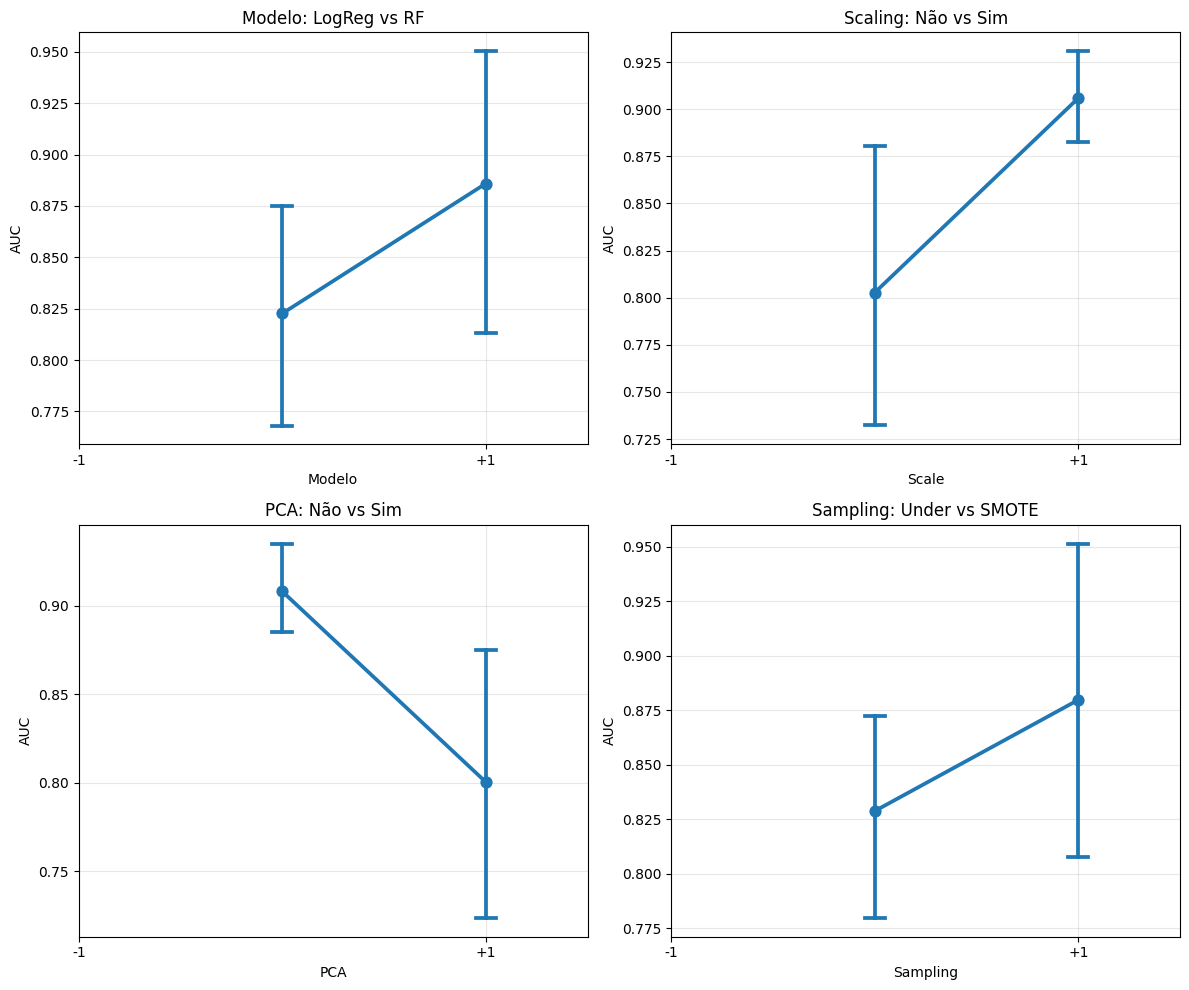

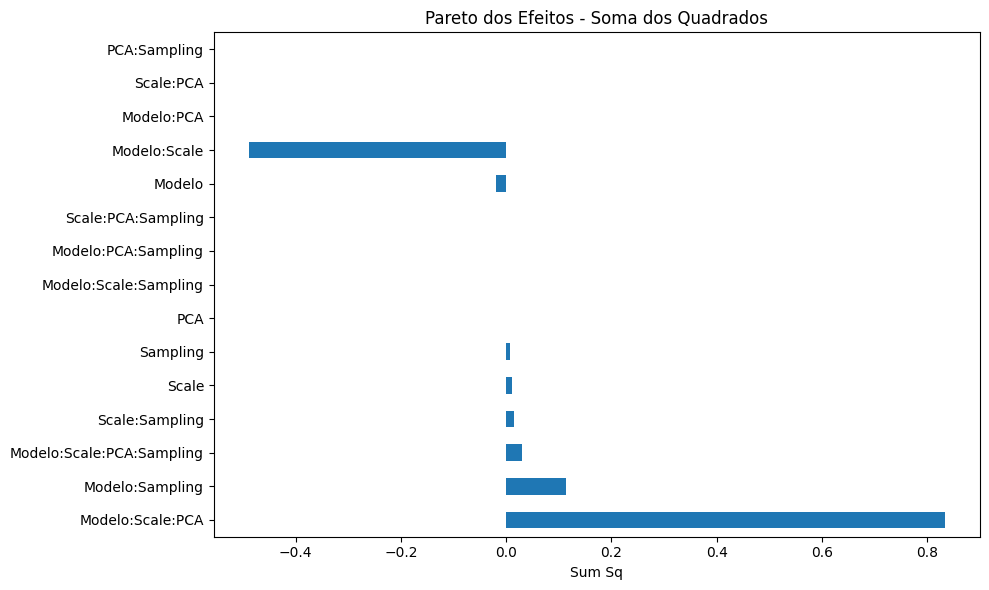


=== MELHOR COMBINAÇÃO ===
Modelo      1.000000
Scale      -1.000000
PCA        -1.000000
Sampling    1.000000
run         5.000000
AUC         0.984785
Name: 4, dtype: float64

Interpreta:
Modelo: RF
Scale: Não
PCA: Não
Sampling: SMOTE
AUC média CV: 0.9848

=== PERFORMANCE NO TESTE ===
AUC Teste: 0.9312

Matriz de Confusão:
[[263  14]
 [ 12  31]]

Classification Report:
              precision    recall  f1-score   support

         Bad       0.96      0.95      0.95       277
        Good       0.69      0.72      0.70        43

    accuracy                           0.92       320
   macro avg       0.82      0.84      0.83       320
weighted avg       0.92      0.92      0.92       320



In [9]:
!pip install pandas scikit-learn SALib imbalanced-learn matplotlib statsmodels --quiet
#*Código completo Python:*
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from SALib.sample import ff
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#1. CARREGA DADOS
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=';')

#Classificação binária: Good >= 7
wine['quality_bin'] = (wine['quality'] >= 7).astype(int)
X = wine.drop(['quality', 'quality_bin'], axis=1)
y = wine['quality_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")
print(f"Distribuição classes: {np.bincount(y_train)}")

#2. PLANEJA FATORIAL 2^4
#Fator A: Modelo -> -1=LogReg, +1=RF
#Fator B: Scale -> -1=Não, +1=Sim
#Fator C: PCA -> -1=Não, +1=Sim
#Fator D: Sampling -> -1=Under, +1=SMOTE

k = 4 # Number of factors
problem = {
    'num_vars': k,
    'names': [f'Fator {i+1}' for i in range(k)],
    'bounds': [[-1, 1]] * k
}
fatores = ff.sample(problem)

n_reps = 3
plano = np.repeat(fatores, n_reps, axis=0)
np.random.seed(42)
np.random.shuffle(plano)

df_plano = pd.DataFrame(plano, columns=['Modelo', 'Scale', 'PCA', 'Sampling'])
df_plano['run'] = range(1, len(df_plano) + 1)
print("\nPlano Experimental 2^4 com 3 reps = 48 rodadas:")
print(df_plano.head(10))

#3. FUNÇÃO QUE RODA 1 EXPERIMENTO
def rodar_experimento(modelo, scale, pca, sampling, X_tr, y_tr):

    # Define pipeline baseado nos níveis
    steps = []

    # Sampling: Under ou SMOTE
    if sampling == -1:
        sampler = RandomUnderSampler(random_state=42)
    else:
        sampler = SMOTE(random_state=42)

    X_res, y_res = sampler.fit_resample(X_tr, y_tr)

    # Scale
    if scale == 1:
        steps.append(('scaler', StandardScaler()))

    # PCA
    if pca == 1:
        steps.append(('pca', PCA(n_components=0.95)))

    # Modelo com tuneLength=5
    if modelo == -1:
        clf = LogisticRegression(max_iter=1000, random_state=42)
        param_grid = {'clf__C': [0.001, 0.01, 0.1, 1, 10]}
    else:
        clf = RandomForestClassifier(random_state=42)
        param_grid = {'clf__n_estimators': [50, 100, 200, 300, 500]}

    steps.append(('clf', clf))
    pipe = Pipeline(steps)

    # GridSearchCV 5-fold = tuneLength 5
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_res, y_res)

    return grid.best_score_ # Melhor AUC no CV

#4. RODA TODOS OS EXPERIMENTOS
print("\nRodando 48 experimentos... demora 5-10 min")
results = []
for idx, row in df_plano.iterrows():
    auc = rodar_experimento(
        row['Modelo'], row['Scale'], row['PCA'], row['Sampling'],
        X_train, y_train
    )
    results.append(auc)
    if (idx + 1) % 8 == 0:
        print(f"Progresso: {idx + 1}/48")

df_plano['AUC'] = results
print("\nResultados:")
print(df_plano.groupby(['Modelo', 'Scale', 'PCA', 'Sampling'])['AUC'].mean().round(4))

#5. ANOVA - ANALISA EFEITOS
#Converte -1/+1 pra 0/1 pra statsmodels
df_anova = df_plano.copy()
for col in ['Modelo', 'Scale', 'PCA', 'Sampling']:
    df_anova[col] = df_anova[col].map({-1: 0, 1: 1})

#Modelo com todas interações até 2ª ordem
formula = 'AUC ~ Modelo * Scale * PCA * Sampling'
modelo_aov = ols(formula, data=df_anova).fit()
tabela_anova = sm.stats.anova_lm(modelo_aov, typ=2)

print("\n=== ANOVA ===")
print(tabela_anova.round(4))

#6. GRÁFICOS DE EFEITOS PRINCIPAIS
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fatores_nome = ['Modelo', 'Scale', 'PCA', 'Sampling']
titulos = ['Modelo: LogReg vs RF', 'Scaling: Não vs Sim',
           'PCA: Não vs Sim', 'Sampling: Under vs SMOTE']

for ax, fator, titulo in zip(axes.flat, fatores_nome, titulos):
    sns.pointplot(x=fator, y='AUC', data=df_plano, ax=ax, capsize=.1)
    ax.set_title(titulo)
    ax.set_xticks([-1, 1])
    ax.set_xticklabels(['-1', '+1'])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('efeitos_principais.png', dpi=150)
plt.show()

#7. PARETO DOS EFEITOS
efeitos = tabela_anova['sum_sq'][:-1] # Remove Residual
efeitos = efeitos.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
efeitos.plot(kind='barh')
plt.title('Pareto dos Efeitos - Soma dos Quadrados')
plt.xlabel('Sum Sq')
plt.tight_layout()
plt.savefig('pareto_efeitos.png', dpi=150)
plt.show()

#8. MELHOR COMBINAÇÃO E TESTE FINAL
melhor_idx = df_plano['AUC'].idxmax()
melhor = df_plano.loc[melhor_idx]
print("\n=== MELHOR COMBINAÇÃO ===")
print(melhor)
print(f"\nInterpreta:")
print(f"Modelo: {'RF' if melhor['Modelo']==1 else 'LogReg'}")
print(f"Scale: {'Sim' if melhor['Scale']==1 else 'Não'}")
print(f"PCA: {'Sim' if melhor['PCA']==1 else 'Não'}")
print(f"Sampling: {'SMOTE' if melhor['Sampling']==1 else 'UnderSampler'}")
print(f"AUC média CV: {melhor['AUC']:.4f}")

#Treina modelo final e testa
if melhor['Sampling'] == -1:
    X_tr_final, y_tr_final = RandomUnderSampler(random_state=42).fit_resample(X_train, y_train)
else:
    X_tr_final, y_tr_final = SMOTE(random_state=42).fit_resample(X_train, y_train)

steps_final = []
if melhor['Scale'] == 1:
    steps_final.append(('scaler', StandardScaler()))
if melhor['PCA'] == 1:
    steps_final.append(('pca', PCA(n_components=0.95)))

if melhor['Modelo'] == -1:
    clf_final = LogisticRegression(max_iter=1000, C=1, random_state=42)
else:
    clf_final = RandomForestClassifier(n_estimators=200, random_state=42)

steps_final.append(('clf', clf_final))
pipe_final = Pipeline(steps_final)
pipe_final.fit(X_tr_final, y_tr_final)

y_pred = pipe_final.predict(X_test)
y_prob = pipe_final.predict_proba(X_test)[:, 1]

print("\n=== PERFORMANCE NO TESTE ===")
print(f"AUC Teste: {roc_auc_score(y_test, y_prob):.4f}")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Bad', 'Good']))